# Hourly airport observations

Local Climatological Data (LCD) is NOAA's record of the weather reports
issued at U.S. airports and other first-order stations: the routine hourly
METAR, special reports when conditions change between hours, synoptic
reports, and the daily and monthly summaries NCEI derives from them. NCEI
publishes it through its Access Data Service, and one request returns one CSV
with a row per report.

This walkthrough pulls three days, 6 to 8 May 2024, at Will Rogers World
Airport in Oklahoma City: hourly temperature and precipitation beside each
day's summary maximum, minimum, and precipitation. The evening of 6 May
brought thunderstorms to central Oklahoma. It needs `usdata[pandas]` and
matplotlib, downloads about 12 kB, and runs in a few seconds.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-25T15:36:46+00:00
usdata 0.27.0; pandas 3.0.6


## Select

The manifest names one station, five columns, and three whole calendar days.
LCD station ids are eleven digits, a five-digit WMO index followed by the
six-digit WBAN number: `72353013967` is the airport. The GHCN id
`USW00013967` or the bare WBAN `13967` are accepted by the service but return
no rows, so a `bbox` or `place` query is the reliable way to find an id.
Without `variables`, every row carries 125 columns. `units: metric` asks for
degrees Celsius and millimetres.

In [2]:
print(manifest.read_text())

name: okc-hourly-observations
sources:
  - dataset: noaa:lcd
    start: 2024-05-06
    end: 2024-05-08
    variables:
      - HourlyDryBulbTemperature
      - HourlyPrecipitation
      - DailyMaximumDryBulbTemperature
      - DailyMinimumDryBulbTemperature
      - DailyPrecipitation
    params:
      stations: "72353013967"
      units: metric



## What arrives

The first pull downloads one CSV and writes `dataset.lock.json` beside the
manifest, pinning the file's checksum. NCEI revises LCD as reports pass
quality control, so a later pull of the same days can return different
bytes; the lockfile records which ones this analysis used.

In [3]:
result = pull(manifest)
(item,) = result.fetched
print("File:", item.path.name)
print("Bytes:", item.provenance.size)
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat(timespec="seconds"))
print("Checksum:", item.provenance.checksum)

File: local-climatological-data_2024-05-06_2024-05-08_0a46d27282eb.csv
Bytes: 11955
Source: https://www.ncei.noaa.gov/access/services/data/v1?dataset=local-climatological-data&stations=72353013967&startDate=2024-05-06&endDate=2024-05-08&format=csv&units=metric&includeStationLocation=1&dataTypes=HourlyDryBulbTemperature%2CHourlyPrecipitation%2CDailyMaximumDryBulbTemperature%2CDailyMinimumDryBulbTemperature%2CDailyPrecipitation
Retrieved (UTC): 2026-09-25T15:36:47+00:00
Checksum: sha256:b00d871956217f95d3c992f77cc5735229e4c6bc002ec6a11c4ceecfbd92c2e4


## Open

The generic CSV reader returns a DataFrame with one row per report. `DATE` is
the station's local standard time with no offset, UTC-6 at Oklahoma City all
year, with no daylight saving shift: it is not a UTC instant. `REPORT_TYPE`
says what each row is, and carries trailing spaces. The hourly columns are
filled on observation reports and the daily columns only on the `SOD`
summary row. `HourlyPrecipitation` arrives as text because a trace is `T`.

In [4]:
frame = item.open_csv(parse_dates=["DATE"])
frame["REPORT_TYPE"] = frame["REPORT_TYPE"].str.strip()
print(f"{len(frame)} reports, {frame['DATE'].min()} to {frame['DATE'].max()} local standard time")
print(frame["REPORT_TYPE"].value_counts().to_string())
frame[["DATE", "REPORT_TYPE", "HourlyDryBulbTemperature", "HourlyPrecipitation"]].head(6)

125 reports, 2024-05-06 00:00:00 to 2024-05-08 23:59:00 local standard time
REPORT_TYPE
FM-15    72
FM-16    31
FM-12    19
SOD       3


,DATE,REPORT_TYPE,HourlyDryBulbTemperature,HourlyPrecipitation
0,2024-05-06 00:00:00,FM-12,16.1,NaN
1,2024-05-06 00:52:00,FM-15,16.1,0.00
2,2024-05-06 01:19:00,FM-16,15.6,NaN
3,2024-05-06 01:52:00,FM-15,15.6,0.00
4,2024-05-06 02:52:00,FM-15,16.1,0.00
5,2024-05-06 03:00:00,FM-12,16.1,NaN


The report types here are routine hourly METARs (`FM-15`, issued at 52
minutes past each hour at this station), specials (`FM-16`), synoptic reports
(`FM-12`), and the summary of the day (`SOD`), stamped 23:59.

In [5]:
hourly = frame[frame["REPORT_TYPE"] == "FM-15"].copy()
special = frame[frame["REPORT_TYPE"] == "FM-16"]
summary = frame[frame["REPORT_TYPE"] == "SOD"]
summary = summary.set_index(summary["DATE"].dt.date.rename("DAY"))
hourly["PRECIP_MM"] = pd.to_numeric(hourly["HourlyPrecipitation"].replace("T", "0"))
summary[["DailyMaximumDryBulbTemperature", "DailyMinimumDryBulbTemperature", "DailyPrecipitation"]]

,DailyMaximumDryBulbTemperature,DailyMinimumDryBulbTemperature,DailyPrecipitation
DAY,,,
2024-05-06,27.2,15.6,10.92
2024-05-07,26.7,11.7,0.00
2024-05-08,26.7,17.2,0.00


## A first look

Three days of temperature, with the special reports between the hours and
each day's summary maximum and minimum, above the hourly precipitation.

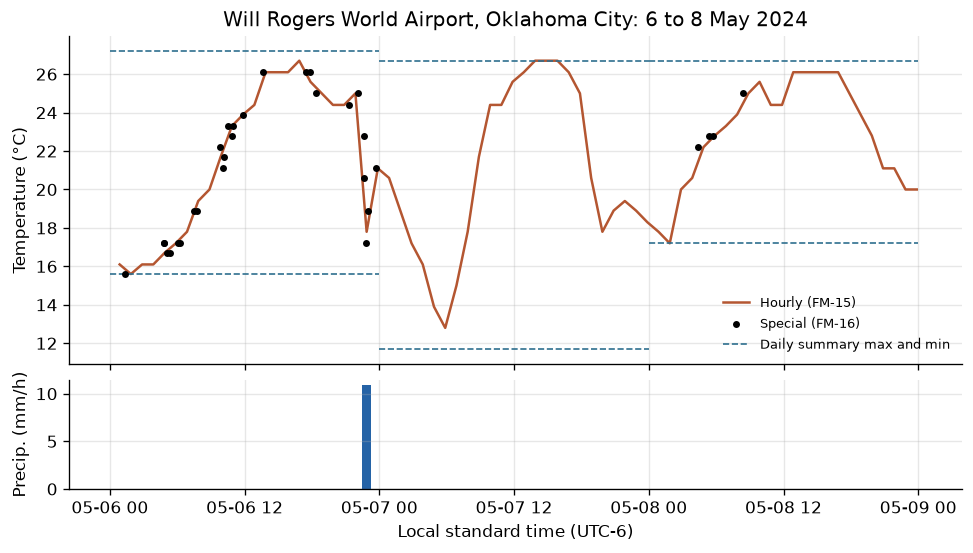

In [6]:
fig, (warm, wet) = plt.subplots(
    2, 1, sharex=True, layout="constrained", gridspec_kw={"height_ratios": [3, 1]}
)
warm.plot(
    hourly["DATE"], hourly["HourlyDryBulbTemperature"], color="#b45631", label="Hourly (FM-15)"
)
warm.scatter(
    special["DATE"],
    special["HourlyDryBulbTemperature"],
    color="black",
    s=10,
    zorder=3,
    label="Special (FM-16)",
)
for day, row in summary.iterrows():
    start = pd.Timestamp(day)
    end = start + pd.Timedelta(days=1)
    for column in ["DailyMaximumDryBulbTemperature", "DailyMinimumDryBulbTemperature"]:
        warm.hlines(row[column], start, end, color="#2f6f8f", linestyle="--", linewidth=1)
warm.plot([], [], color="#2f6f8f", linestyle="--", linewidth=1, label="Daily summary max and min")
warm.set_ylabel("Temperature (°C)")
warm.set_title("Will Rogers World Airport, Oklahoma City: 6 to 8 May 2024")
warm.legend(loc="lower right", fontsize=8, frameon=False)
wet.bar(hourly["DATE"], hourly["PRECIP_MM"], width=pd.Timedelta(minutes=50), color="#2563a6")
wet.set_ylabel("Precip. (mm/h)")
wet.set_xlabel("Local standard time (UTC-6)")
plt.show()

In [7]:
check = hourly.groupby(hourly["DATE"].dt.date).agg(
    HOURLY_MAX=("HourlyDryBulbTemperature", "max"),
    HOURLY_MIN=("HourlyDryBulbTemperature", "min"),
    HOURLY_PRECIP=("PRECIP_MM", "sum"),
)
check = check.join(
    summary[
        ["DailyMaximumDryBulbTemperature", "DailyMinimumDryBulbTemperature", "DailyPrecipitation"]
    ]
)
storm = special[(special["DATE"] >= "2024-05-06 22:00") & (special["DATE"] < "2024-05-07")]
print(check.to_string())
print()
print(storm[["DATE", "HourlyDryBulbTemperature", "HourlyPrecipitation"]].to_string(index=False))

            HOURLY_MAX  HOURLY_MIN  HOURLY_PRECIP  DailyMaximumDryBulbTemperature  DailyMinimumDryBulbTemperature  DailyPrecipitation
DATE                                                                                                                                 
2024-05-06        26.7        15.6          10.92                            27.2                            15.6               10.92
2024-05-07        26.7        12.8           0.00                            26.7                            11.7                0.00
2024-05-08        26.1        17.2           0.00                            26.7                            17.2                0.00

               DATE  HourlyDryBulbTemperature HourlyPrecipitation
2024-05-06 22:04:00                      25.0                 NaN
2024-05-06 22:38:00                      22.8                1.52
2024-05-06 22:40:00                      20.6                2.79
2024-05-06 22:50:00                      17.2                 NaN

The storm on the evening of 6 May shows in the specials: the temperature fell
7.8 °C, from 25.0 °C at 22:04 to 17.2 °C at 22:50, between two hourly
reports, and the day's whole 10.92 mm arrived in the hourly report at 22:52.
The summary's extremes are not the hourly ones: NCEI takes them from every
report and the station's continuous sensor, so the 6 May maximum is 0.5 °C
above the highest hourly reading and the 7 May minimum 1.1 °C below the
lowest. Summing hourly precipitation, with a trace as zero, reproduces each
day's total.

## Pin and cite

`verify` checks the cached file against the lockfile's checksum. Because NCEI
revises LCD, keep the cache with the manifest and lockfile; a checksum cannot
recreate bytes upstream has replaced. `usdata cite dataset.yaml` prints the
same citation.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:lcd
  NOAA National Centers for Environmental Information, U.S. Local Climatological Data, accessed via usdata
  homepage: https://www.ncei.noaa.gov/products/land-based-station/local-climatological-data
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00684/html
  retrieved: 2026-09-25; 1 checksummed asset (11,955 bytes) pinned by usdata 0.27.0
  sources: 1


## What was awkward

- `DATE` is local standard time with no offset. Parsing it gives naive
  timestamps that look like UTC or local clock time and are neither; joining
  with UTC data needs an explicit `+6 h` here, and the offset differs by
  station.
- Every report type shares one table. Aggregating without filtering on
  `REPORT_TYPE` mixes hourly, special, and synoptic reports and the daily
  summary row, and `REPORT_TYPE` needs `.str.strip()` before comparing.
- Precipitation is text because a trace is `T`, and values elsewhere can
  carry quality suffixes such as `s`, so numeric columns need an explicit
  coercion that decides what a trace is worth.
- The obvious station ids (`USW00013967`, `13967`) return a header and no
  rows rather than an error.
- The CSV carries no units; the manifest's `units: metric` is the only record
  of them. The [LCD guide](https://docs.usdata.dev/providers/noaa-lcd/) links
  NCEI's documentation for each column's unit.